In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import sys 
import json 

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils.utils import fill_time_template, split_train_test_time, feature_engineering, impute_missing_values

In [3]:
data = pd.read_csv('../data/supply_raw_1month.csv', index_col=0)

In [4]:
data['block_start_time'] = pd.to_datetime(data['block_start_time'])
data['block_end_time'] = pd.to_datetime(data['block_end_time'])


In [5]:
data.drop(columns = ['block_end_time'],inplace=True)

In [6]:
data.head(3)

,block_start_time,hex_id,vehicle_type,suppliers_online
0,2026-02-28 23:50:00,8765b565bffffff,VAN-1000,1
1,2026-03-01 00:00:00,8765b1914ffffff,VAN-500,1
2,2026-03-01 00:00:00,8765b1930ffffff,VAN-1000,1


#### 1/ Add template: 

In [7]:
print(data['block_start_time'].min())
print(data['block_start_time'].max())

2026-02-28 23:50:00
2026-04-01 00:00:00


In [8]:
data.shape

(813587, 4)

In [9]:
df_test = fill_time_template(data, data['block_start_time'].min(), data['block_start_time'].max(), '10min')

In [10]:
df_test

,hex_id,vehicle_type,block_start_time,suppliers_online
0,8765b565bffffff,VAN-1000,2026-02-28 23:50:00,1.0
1,8765b565bffffff,VAN-1000,2026-03-01 00:00:00,0.0
2,8765b565bffffff,VAN-1000,2026-03-01 00:10:00,0.0
3,8765b565bffffff,VAN-1000,2026-03-01 00:20:00,0.0
4,8765b565bffffff,VAN-1000,2026-03-01 00:30:00,0.0
...,...,...,...,...
8016465,8765b18a1ffffff,TRICYCLE,2026-03-31 23:20:00,0.0
8016466,8765b18a1ffffff,TRICYCLE,2026-03-31 23:30:00,0.0
8016467,8765b18a1ffffff,TRICYCLE,2026-03-31 23:40:00,0.0
8016468,8765b18a1ffffff,TRICYCLE,2026-03-31 23:50:00,0.0


In [11]:
df_eng = feature_engineering(df_test)

In [14]:
df_impute = impute_missing_values(df_eng)

In [15]:
train_df, test_df = split_train_test_time(df_impute, 0.8, peak=1)

2026-03-02 → 2026-03-25
2026-03-26 → 2026-03-31


#### Baseline: 

In [17]:
train_df = pd.get_dummies(train_df, columns = ['vehicle_type'])

In [19]:
train_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [20]:
X = train_df.drop(columns = ['suppliers_online'])
y = train_df['suppliers_online']

In [21]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

xgb_model_peak = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_peak.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [22]:
test_df =  pd.get_dummies(test_df, columns = ['vehicle_type'])

X_test = test_df.drop(columns = ['block_start_time','hex_id','date','suppliers_online'])
y_test = test_df[['suppliers_online']]

y_pred = xgb_model_peak.predict(X_test)

In [24]:
def cal_smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

In [31]:
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0
    return np.mean(diff) * 100

In [ ]:
def wape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return (
        np.sum(np.abs(y_true - y_pred))
        / np.sum(np.abs(y_true))
    ) * 100

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("MSE:", mse)

smape_value = wape(y_test['suppliers_online'], y_pred)
print("WAPE:",smape_value)

R2: 0.8385629653930664
MSE: 0.2434830367565155
WAPE: 52.93066651763251


#### Evaluate testing: 

In [26]:
test_df['y_pred'] = y_pred
test_df.head(3)

,hex_id,block_start_time,suppliers_online,date,month,weekday,hour,week_of_month,lag_1,lag_2,...,is_peak,vehicle_type_PICKUP-TRUCK,vehicle_type_TRICYCLE,vehicle_type_TRUCK-1000,vehicle_type_TRUCK-1500,vehicle_type_TRUCK-2000,vehicle_type_TRUCK-500,vehicle_type_VAN-1000,vehicle_type_VAN-500,y_pred
1330601,8765b192affffff,2026-03-26 08:00:00,0.0,2026-03-26,3,3,8,4,0.0,0.0,...,1,False,False,False,False,False,False,True,False,0.025532
5244701,8765b5640ffffff,2026-03-26 08:00:00,0.0,2026-03-26,3,3,8,4,0.0,0.0,...,1,True,False,False,False,False,False,False,False,0.013026
5244700,8765b5640ffffff,2026-03-26 08:00:00,0.0,2026-03-26,3,3,8,4,0.0,0.0,...,1,False,False,False,True,False,False,False,False,0.016924


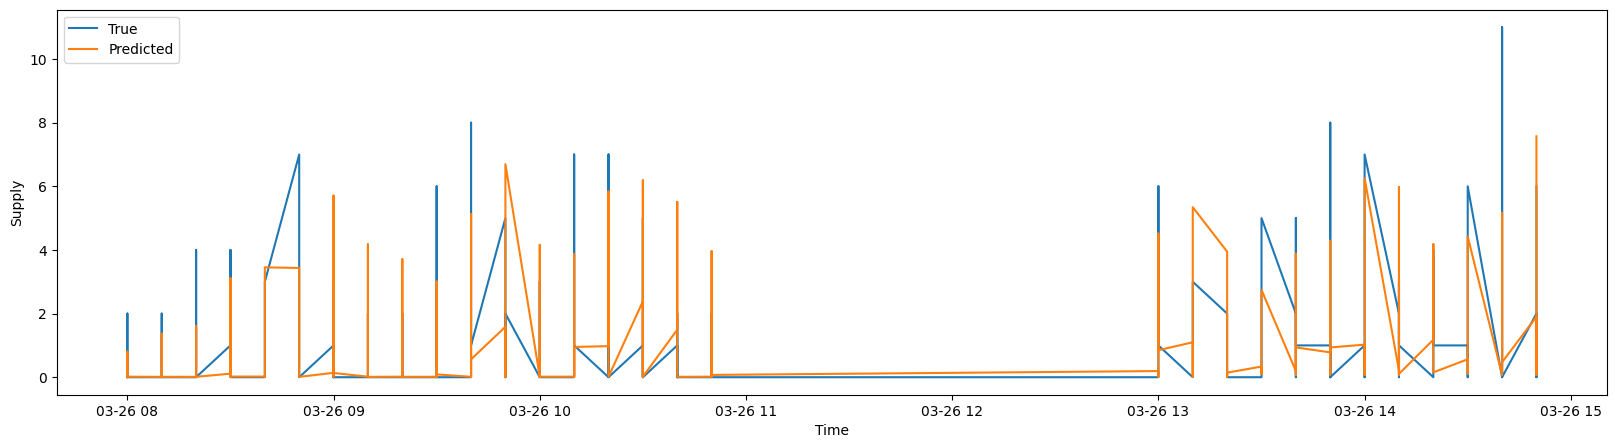

In [29]:
test_df['date'] = pd.to_datetime(test_df['date'])


# plot_df = test_df[test_df['vehicle_type_TRICYCLE']==True]
plot_df = test_df.copy()
plot_df = plot_df[plot_df['date']=='2026-03-26']
plot_df = plot_df[plot_df['hex_id']=='8765b5644ffffff']

plt.figure(figsize=(20, 5))
plt.plot(plot_df['block_start_time'], plot_df['suppliers_online'], label='True')
plt.plot(plot_df['block_start_time'], plot_df['y_pred'], label='Predicted')
plt.xlabel('Time')
plt.ylabel('Supply')
plt.legend()
plt.show()

/var/folders/f5/j3qvvd4923z_49cvx7kg0qnh0000gn/T/ipykernel_27383/1452155227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')


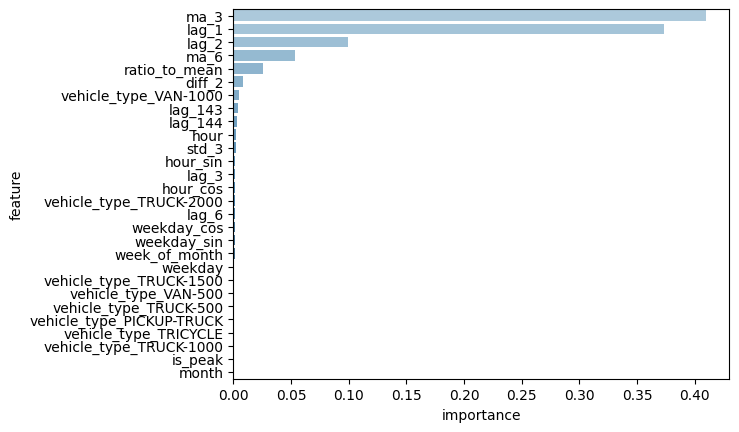

In [28]:
importance = xgb_model_peak.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')
plt.show()

#### Optuna: 

In [39]:
import optuna

def objective(trial):

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",

        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),

        "max_depth": trial.suggest_int("max_depth", 3, 12),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-3,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-5,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10,
            log=True
        ),
    }

    model = xgb.XGBRegressor(**params)

    model.fit(
        X,
        y,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)

    rmse = mean_squared_error(
        y_test,
        preds,
        # squared=False
    )

    return rmse

study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=50)

print(study.best_params)
print(study.best_value)

[I 2026-05-16 15:19:41,580] A new study created in memory with name: no-name-a2ea067b-db39-481e-98ef-11093c248928
[I 2026-05-16 15:19:43,329] Trial 0 finished with value: 1.1354166269302368 and parameters: {'n_estimators': 122, 'max_depth': 3, 'learning_rate': 0.00147967903538937, 'subsample': 0.977886792303984, 'colsample_bytree': 0.6998535940973973, 'min_child_weight': 9, 'gamma': 3.0127224019987295, 'reg_alpha': 2.0754165880636926e-05, 'reg_lambda': 3.450181434381275e-05}. Best is trial 0 with value: 1.1354166269302368.
[I 2026-05-16 15:19:57,454] Trial 1 finished with value: 0.24802513420581818 and parameters: {'n_estimators': 881, 'max_depth': 7, 'learning_rate': 0.04353469327321792, 'subsample': 0.6933007319559799, 'colsample_bytree': 0.9402136028628663, 'min_child_weight': 1, 'gamma': 1.01327749247577, 'reg_alpha': 0.06928260558272827, 'reg_lambda': 0.013600242930183838}. Best is trial 1 with value: 0.24802513420581818.
[I 2026-05-16 15:20:07,037] Trial 2 finished with value: 0.

{'n_estimators': 992, 'max_depth': 6, 'learning_rate': 0.006549101480681001, 'subsample': 0.7898315570983306, 'colsample_bytree': 0.5737443459230903, 'min_child_weight': 3, 'gamma': 3.7689256602879686, 'reg_alpha': 3.765066400923957e-05, 'reg_lambda': 1.1837733326757654e-05}
0.24257715046405792


In [40]:
xgb_best_model = xgb.XGBRegressor(**study.best_params)

xgb_best_model.fit(X,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5737443459230903
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
y_pred_best = xgb_best_model.predict(X_test) 

r2 = r2_score(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)

print("R2:", r2)
print("MSE:", mse)

wape_value = wape(y_test['suppliers_online'], y_pred_best)
print("WAPE:", wape_value)

R2: 0.839163601398468
MSE: 0.24257715046405792
WAPE: 53.09166954911165
